# Assignment 2 

# Imports

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import time

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.decomposition import PCA

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# MPS backend
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


# Part Α: LSTM Forecasting

## Load Data

In [2]:
df = pd.read_csv("dataset.csv")

STATE_COLS = ["u1", "u2", "u3", "u4", "u5",
              "v1", "v2", "v3", "v4", "v5"]

train_df = df[df["split"] == "train"]
test_df  = df[df["split"] == "test"]

# Make every trajectory as (X, F):
#   X : (1001, 10)  includes the STATE_COLS
#   F : (1001,)     forcing at the top node
def load_trajectories(df_split):
    trajs = []
    for tid in sorted(df_split["traj_id"].unique()):
        traj = df_split[df_split["traj_id"] == tid].sort_values("t")
        X = traj[STATE_COLS].values.astype(np.float32)      # (1001, 10)
        F = traj["F_top"].values.astype(np.float32)         # (1001,)
        trajs.append((X, F))
    return trajs

train_trajs = load_trajectories(train_df) # list with tuple (X, F) 
test_trajs  = load_trajectories(test_df) #         -//-

print(f"Train trajectories: {len(train_trajs)}")
print(f"Test  trajectories: {len(test_trajs)}")
print(f"Shape of one X: {train_trajs[0][0].shape}")
print(f"Shape of one F: {train_trajs[0][1].shape}")


Train trajectories: 60
Test  trajectories: 15
Shape of one X: (1001, 10)
Shape of one F: (1001,)


In [3]:
# Stack all the training states
all_X = np.vstack([X for X, F in train_trajs])   # (60*1001, 10)
all_F = np.concatenate([F for X, F in train_trajs])  # (60*1001,)

# Calculate mean and std on the training states only - Normalization Process
X_mean = all_X.mean(axis=0).astype(np.float32)
X_std  = all_X.std(axis=0).astype(np.float32)
X_std  = np.where(X_std < 1e-8, 1.0, X_std) 

F_mean = float(all_F.mean())
F_std  = float(all_F.std())

print("X_mean:", X_mean.round(4))
print("X_std:", X_std.round(4))
print("F_mean:", round(F_mean, 4))
print("F_std: ", round(F_std, 4))

X_mean: [ 1.e-04  2.e-04  3.e-04  5.e-04  6.e-04 -2.e-04 -3.e-04 -3.e-04 -3.e-04
 -2.e-04]
X_std: [0.0235 0.0429 0.0575 0.0688 0.0765 0.1022 0.1595 0.1728 0.1905 0.2226]
F_mean: 0.0112
F_std:  0.7476


## Creating a custom Dataset

In [4]:
WINDOW_P = 20  # number of p states 

class TrajectoryDataset(Dataset):
    def __init__(self, trajectories, window_p):
        self.samples = []  # list of (input, target) tuples

        for X, F in trajectories:
            # Normalization
            X_norm = (X - X_mean) / X_std          # (1001, 10)
            F_norm = (F - F_mean) / F_std           # (1001,)

            # state  + force into one array (1001, 11)
            XF = np.column_stack([X_norm, F_norm])  # (1001, 11)

            # Sliding window
            for start in range(len(XF) - window_p):
                end = start + window_p

                inp = XF[start:end]       # (p_state, 11) — input
                tgt = XF[end, :10]        # (10,)             — target: only state cols

                self.samples.append((
                    torch.tensor(inp, dtype=torch.float32),
                    torch.tensor(tgt, dtype=torch.float32)
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


# Construction of datasets
train_dataset = TrajectoryDataset(train_trajs, WINDOW_P)
test_dataset  = TrajectoryDataset(test_trajs, WINDOW_P)

print(f"Train samples: {len(train_dataset)}")
print(f"Test  samples: {len(test_dataset)}")

# Check one sample
inp, tgt = train_dataset[0]
print(f"\nInput shape : {inp.shape}   (window_p=20, features=11)")
print(f"Target shape: {tgt.shape}  (next state: 10 values)")


Train samples: 58860
Test  samples: 14715

Input shape : torch.Size([20, 11])   (window_p=20, features=11)
Target shape: torch.Size([10])  (next state: 10 values)


## Iterate through the DataLoader

In [5]:
BATCH_SIZE = 256 # power of two 

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True    # shuffle samples in every epoch
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False   # no need for shuffling in test set
)

# Check one batch
X_batch, y_batch = next(iter(train_loader))
print(f"Batch input shape : {X_batch.shape}  (batch, window_p, features)")
print(f"Batch target shape: {y_batch.shape}  (batch, 10)")


Batch input shape : torch.Size([256, 20, 11])  (batch, window_p, features)
Batch target shape: torch.Size([256, 10])  (batch, 10)


## Built LSTM model

In [6]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()

        # LSTM layer
        # input_size  : features in each time step (11)
        # hidden_size : hidden state size
        # num_layers  : LSTM layers stacked

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True
        )

        # Linear layer: hidden_size → output_size (Applies an affine linear transformation to the incoming data)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        # lstm_out: (batch, seq_len, hidden_size)
        # lstm_out[:, -1, :] shape: (batch, hidden_size)
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :] # hidden state at the final timestep

        # out shape: (batch, output_size)
        out = self.linear(last_output)

        return out


# LSTM Paremeters
INPUT_SIZE  = 11   # 10 state cols + 1 force node
HIDDEN_SIZE = 64
NUM_LAYERS  = 1
OUTPUT_SIZE = 10   # next state

model = LSTMModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)
model = model.to(device)

print(model)
print(f"\nTotal Parameters: {sum(p.numel() for p in model.parameters()):,}")


LSTMModel(
  (lstm): LSTM(11, 64, batch_first=True)
  (linear): Linear(in_features=64, out_features=10, bias=True)
)

Total Parameters: 20,362


## Training Loop


In [7]:
# Loss function: MSE
loss_fn   = nn.MSELoss()

# Optimizer: Adam
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Learning rate scheduler — reduces lr when test loss plateaus
# factor=0.5  -> lr_new = lr_old * 0.5
# patience=5  -> wait 5 epochs with no improvement before reducing lr
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

EPOCHS = 150

train_losses = []
test_losses  = []

# Early stopping / checkpointing state
best_test_loss = float('inf')
best_epoch     = -1
patience_es    = 15          # epochs with no improvement before stopping entirely
epochs_no_improve = 0
best_model_state = None

for epoch in range(EPOCHS):

    # Training 
    model.train()
    epoch_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)

    # Evaluation 
    model.eval()
    epoch_test_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)
            loss = loss_fn(pred, y_batch)
            epoch_test_loss += loss.item()

    avg_test_loss = epoch_test_loss / len(test_loader)

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    # Scheduler step (based on test loss)
    scheduler.step(avg_test_loss)

    # Checkpoint if improved
    if avg_test_loss < best_test_loss:
        best_test_loss   = avg_test_loss
        best_epoch       = epoch + 1
        epochs_no_improve = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1

    current_lr = optimizer.param_groups[0]['lr']

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
                f"Train Loss: {avg_train_loss:.3e} | "
                f"Test Loss:  {avg_test_loss:.3e} | "
                f"LR: {current_lr:.2e} | "
                f"Best: {best_test_loss:.3e} @ epoch {best_epoch}")

    # Early stopping
    if epochs_no_improve >= patience_es:
        print(f"\nEarly stopping at epoch {epoch+1} "
              f"(no improvement for {patience_es} epochs)")
        break

# Load the BEST checkpoint, not the last one
model.load_state_dict(best_model_state)
print(f"\nLoaded best model from epoch {best_epoch} "
      f"(test loss = {best_test_loss:.3e})")

Epoch   1/150 | Train Loss: 2.059e-01 | Test Loss:  1.671e-03 | LR: 1.00e-03 | Best: 1.671e-03 @ epoch 1
Epoch   5/150 | Train Loss: 4.042e-04 | Test Loss:  2.066e-04 | LR: 1.00e-03 | Best: 2.066e-04 @ epoch 5
Epoch  10/150 | Train Loss: 1.450e-04 | Test Loss:  6.463e-05 | LR: 1.00e-03 | Best: 6.463e-05 @ epoch 10
Epoch  15/150 | Train Loss: 7.614e-05 | Test Loss:  3.062e-05 | LR: 1.00e-03 | Best: 3.062e-05 @ epoch 15
Epoch  20/150 | Train Loss: 4.224e-05 | Test Loss:  2.548e-05 | LR: 1.00e-03 | Best: 2.548e-05 @ epoch 20
Epoch  25/150 | Train Loss: 4.314e-05 | Test Loss:  3.649e-05 | LR: 1.00e-03 | Best: 1.788e-05 @ epoch 23
Epoch  30/150 | Train Loss: 5.078e-05 | Test Loss:  1.804e-05 | LR: 1.00e-03 | Best: 1.147e-05 @ epoch 27
Epoch  35/150 | Train Loss: 9.139e-06 | Test Loss:  6.958e-06 | LR: 5.00e-04 | Best: 6.958e-06 @ epoch 35
Epoch  40/150 | Train Loss: 1.370e-05 | Test Loss:  7.299e-06 | LR: 5.00e-04 | Best: 6.958e-06 @ epoch 35
Epoch  45/150 | Train Loss: 6.565e-06 | Test Los

## Learning Curves

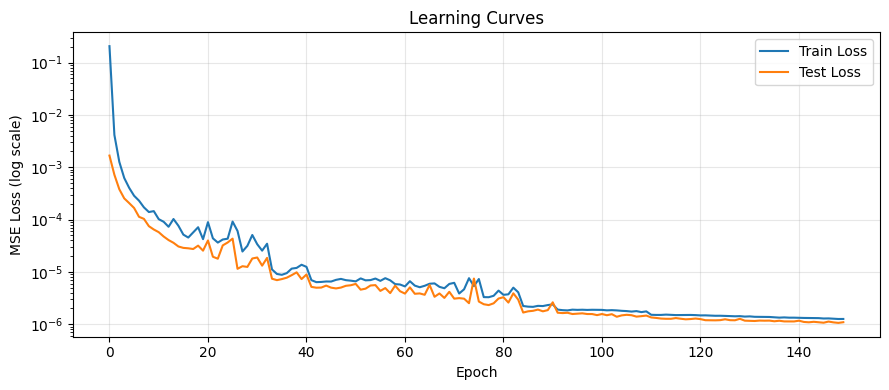

In [8]:
plt.figure(figsize=(9, 4))
plt.semilogy(train_losses, label="Train Loss")
plt.semilogy(test_losses,  label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log scale)")
plt.title("Learning Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("learning_curves.png", dpi=600, bbox_inches="tight")
plt.show()


## One-Step Ahead Prediction


In [28]:
def one_step_ahead(model, X, F):
    """
    X: (1001, 10) unnormalized state
    F: (1001,)    unnormalized force
    Returns: (1001 - WINDOW_P, 10) predictions in original scale
    """
    # Normalization
    X_norm = (X - X_mean) / X_std
    F_norm = (F - F_mean) / F_std
    XF = np.column_stack([X_norm, F_norm]).astype(np.float32)  # (1001, 11)

    
    windows = np.stack([XF[s:s+WINDOW_P] for s in range(len(XF)-WINDOW_P)])
    # windows shape: (1001 - WINDOW_P, WINDOW_P, 11)

    model.eval()
    with torch.no_grad():
        inp  = torch.tensor(windows).to(device)
        pred = model(inp).cpu().numpy()   # (1001 - WINDOW_P, 10) — normalized

    # Denormalize
    return pred * X_std + X_mean


# Evaluation in one trajectory
traj_num = 8
X_test0, F_test0 = test_trajs[traj_num]
preds_1step = one_step_ahead(model, X_test0, F_test0)
targets     = X_test0[WINDOW_P:]   # ground truth

rmse_per_dof = np.sqrt(np.mean((preds_1step - targets)**2, axis=0))
print(f"RMSE per Degree of Freedom (one-step, test traj {traj_num}):")
for col, r in zip(STATE_COLS, rmse_per_dof):
    print(f"  {col}: {r:.4e}")


RMSE per Degree of Freedom (one-step, test traj 8):
  u1: 4.9152e-06
  u2: 8.2393e-06
  u3: 5.4972e-06
  u4: 1.2973e-05
  u5: 1.8102e-05
  v1: 6.1062e-05
  v2: 1.1782e-04
  v3: 8.1430e-05
  v4: 9.9796e-05
  v5: 9.9383e-05


## Autoregressive Rollout


In [29]:
def autoregressive_rollout(model, X, F):
    """
    X: (1001, 10) unnormalized
    F: (1001,)    unnormalized
    Returns: (1001 - WINDOW_P, 10) predictions in original scale
    """
    X_norm = (X - X_mean) / X_std
    F_norm = (F - F_mean) / F_std

    # Start from the p real state variables
    buffer = X_norm[:WINDOW_P].astype(np.float32).copy()  # (p, 10)

    preds = []

    model.eval()
    with torch.no_grad():
        for step in range(len(X_norm) - WINDOW_P):
            
            F_window = F_norm[step:step+WINDOW_P].astype(np.float32)  # (p,)

            # Input construction 
            inp = np.column_stack([buffer, F_window])    # (p, 11)
            inp_tensor = torch.tensor(inp).unsqueeze(0).to(device)  # (1, p, 11)

            # Predict next state
            pred = model(inp_tensor).cpu().numpy()[0]    # (10,)
            preds.append(pred)

            # Update buffer
            buffer[:-1] = buffer[1:]
            buffer[-1]  = pred

    preds = np.array(preds)           # (1001 - WINDOW_P, 10) — normalized
    return preds * X_std + X_mean     # denormalize


preds_auto = autoregressive_rollout(model, X_test0, F_test0)
rmse_auto  = np.sqrt(np.mean((preds_auto - targets)**2, axis=0))

print(f"RMSE per Degree of Freedom (autoregressive, test traj {traj_num}):")
print(f"{'DOF':<6} | {'One-step':>10} | {'Autoregressive':>14}")
print("-" * 36)
for col, r1, ra in zip(STATE_COLS, rmse_per_dof, rmse_auto):
    print(f"{col:<6} | {r1:>10.3e} | {ra:>14.3e}")


RMSE per Degree of Freedom (autoregressive, test traj 8):
DOF    |   One-step | Autoregressive
------------------------------------
u1     |  4.915e-06 |      3.559e-04
u2     |  8.239e-06 |      6.791e-04
u3     |  5.497e-06 |      9.473e-04
u4     |  1.297e-05 |      1.139e-03
u5     |  1.810e-05 |      1.240e-03
v1     |  6.106e-05 |      1.103e-03
v2     |  1.178e-04 |      2.000e-03
v3     |  8.143e-05 |      2.752e-03
v4     |  9.980e-05 |      3.272e-03
v5     |  9.938e-05 |      3.607e-03


## Comparing plots


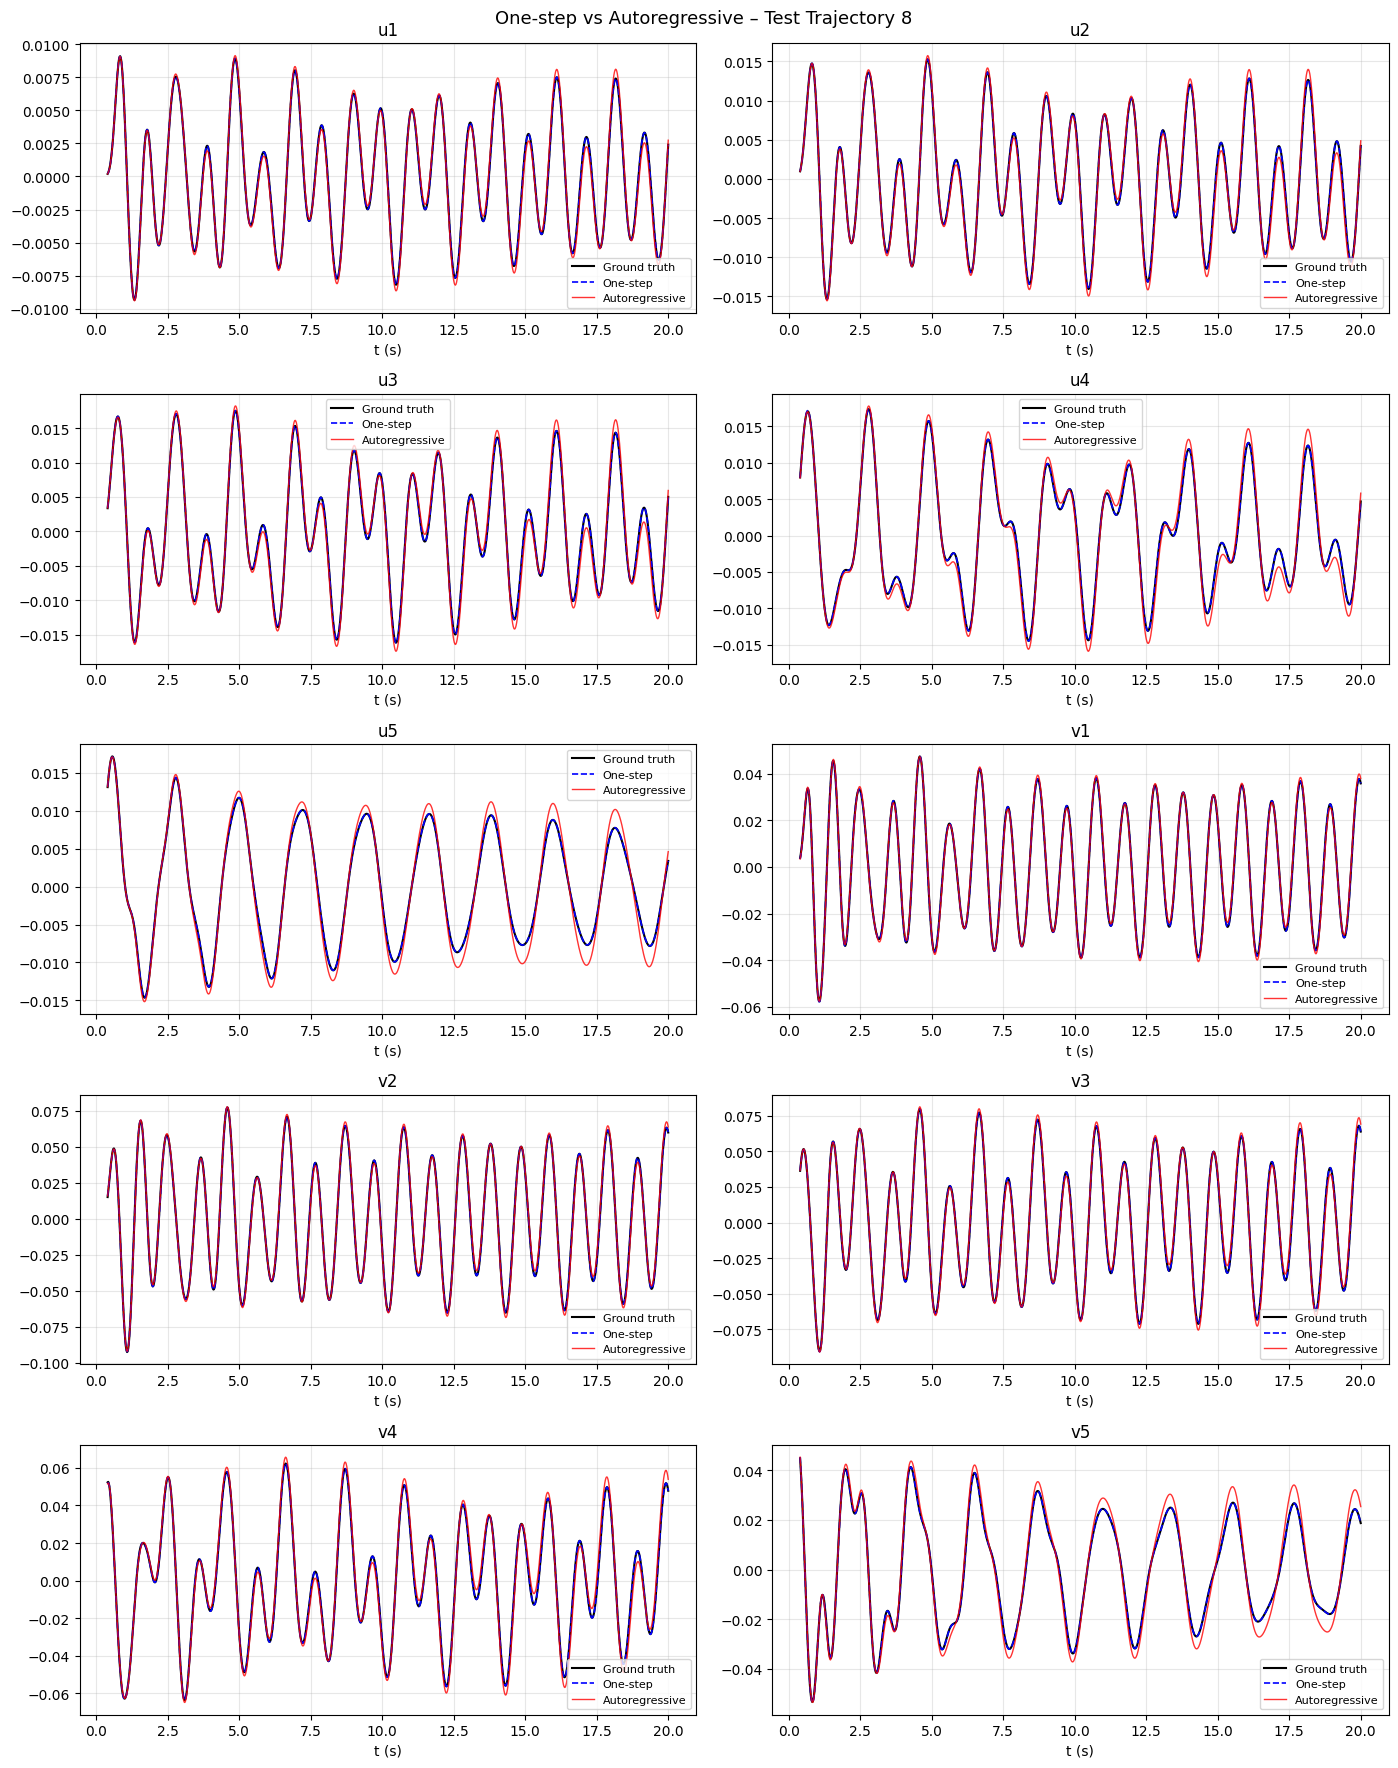

In [30]:
time_step = 0.02
t_axis = np.arange(1001) * time_step    
t_pred = t_axis[WINDOW_P:]

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
fig.suptitle(f"One-step vs Autoregressive – Test Trajectory {traj_num}", fontsize=13)

for ax, dof, label in zip(axes.flat, range(10), STATE_COLS):
    ax.plot(t_pred, targets[:,dof],      "k-",  lw=1.5, label="Ground truth")
    ax.plot(t_pred, preds_1step[:,dof],  "b--", lw=1.2, label="One-step")
    ax.plot(t_pred, preds_auto[:,dof],   "r-",  lw=1.0, label="Autoregressive", alpha=0.8)
    ax.set_xlabel("t (s)")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("one_step_vs_autoregressive.png", dpi=600, bbox_inches="tight")
plt.show()

## Error accumulation in time

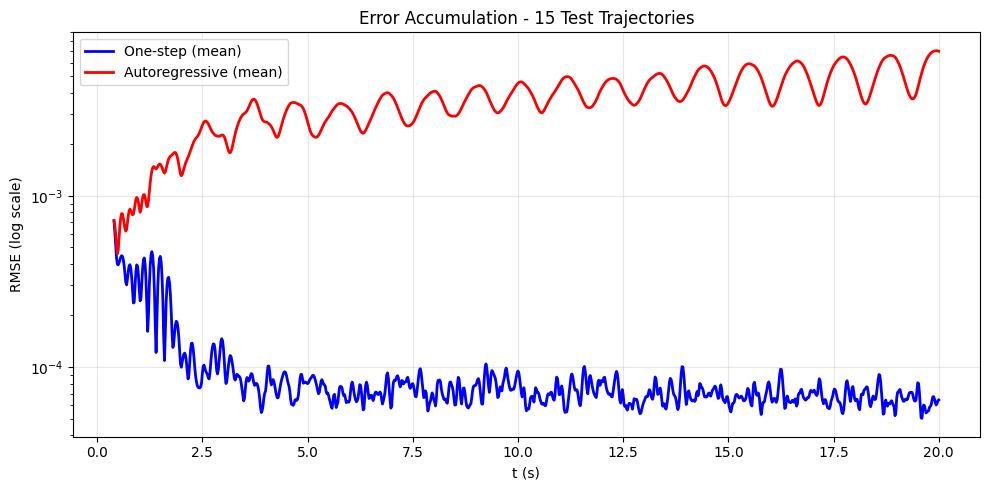

RMSE one-step  στο t=20s: 6.420e-05
RMSE autoregr. στο t=20s: 6.997e-03


In [ ]:
# Calculate RMSE in every timestep for all trajectories
all_err_1step = []
all_err_auto  = []

for X, F in test_trajs:
    p1  = one_step_ahead(model, X, F)
    par = autoregressive_rollout(model, X, F)
    tgt = X[WINDOW_P:]

    all_err_1step.append(np.sqrt(np.mean((p1  - tgt)**2, axis=1)))
    all_err_auto.append( np.sqrt(np.mean((par - tgt)**2, axis=1)))

all_err_1step = np.array(all_err_1step)   # (15, 1001 - WINDOW_P)
all_err_auto  = np.array(all_err_auto)    # (15, 1001 - WINDOW_P)

m1 = all_err_1step.mean(axis=0)
ma = all_err_auto.mean(axis=0)

plt.figure(figsize=(10, 5))
plt.semilogy(t_pred, m1, "b-", lw=2, label="One-step (mean)")
plt.semilogy(t_pred, ma, "r-", lw=2, label="Autoregressive (mean)")
plt.xlabel("t (s)")
plt.ylabel("RMSE (log scale)")
plt.title("Error Accumulation - 15 Test Trajectories")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("error_accumulation.png", dpi=600, bbox_inches="tight")
plt.show()

print(f"RMSE one-step  στο t=20s: {m1[-1]:.3e}")
print(f"RMSE autoregr. στο t=20s: {ma[-1]:.3e}")

## Save trained Model


In [34]:
torch.save({
    "model_state_dict": model.state_dict(),
    "model_config": {
        "input_size":  INPUT_SIZE,
        "hidden_size": HIDDEN_SIZE,
        "num_layers":  NUM_LAYERS,
        "output_size": OUTPUT_SIZE,
        "window_size": WINDOW_P,
    },
    "X_mean": X_mean,
    "X_std":  X_std,
    "F_mean": F_mean,
    "F_std":  F_std,
}, "lstm_part_a.pth")

print("Saved: lstm_part_a.pth")

Saved: lstm_part_a.pth


## Ablation Study

In [36]:
# We test one hyperparameter at a time, keeping the others fixed at baseline.
# Baseline: p=20, hidden_size=64, num_layers=1

ABLATION_EPOCHS = 50 # train for smaller number of epochs for faster results
BASELINE_P           = 20
BASELINE_HIDDEN_SIZE = 64
BASELINE_NUM_LAYERS  = 1

def run_experiment(window_p, hidden_size, num_layers, epochs=ABLATION_EPOCHS):
    """Train a model with given hyperparameters and return the best test loss."""

    # Build dataset with the given window size
    train_ds = TrajectoryDataset(train_trajs, window_p)
    test_ds  = TrajectoryDataset(test_trajs,  window_p)
    train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_ld  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

    # Build model
    m = LSTMModel(INPUT_SIZE, hidden_size, num_layers, OUTPUT_SIZE).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    best_loss = float('inf')
    t0 = time.time()

    for epoch in range(epochs): 
        # Training
        m.train()
        for Xb, yb in train_ld:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(m(Xb), yb)
            loss.backward()
            opt.step()

        # Evaluation
        m.eval()
        epoch_loss = 0.0
        with torch.no_grad():
            for Xb, yb in test_ld:
                Xb, yb = Xb.to(device), yb.to(device)
                epoch_loss += loss_fn(m(Xb), yb).item()
        avg_loss = epoch_loss / len(test_ld)
        if avg_loss < best_loss:
            best_loss = avg_loss

    elapsed = time.time() - t0
    return best_loss, elapsed


# (i) Window size p 
print("=" * 55)
print("(i) Effect of window size p")
print("=" * 55)
results_p = {}
for p in [10, 20, 50]:
    loss, t = run_experiment(p, BASELINE_HIDDEN_SIZE, BASELINE_NUM_LAYERS)
    results_p[p] = loss
    tag = " ← baseline" if p == BASELINE_P else ""
    print(f"  p={p:>3} | Test Loss: {loss:.3e} | Time: {t:.1f}s{tag}")

# (ii) Hidden size 
print()
print("=" * 55)
print("(ii) Effect of hidden size")
print("=" * 55)
results_h = {}
for h in [32, 64, 128]:
    loss, t = run_experiment(BASELINE_P, h, BASELINE_NUM_LAYERS)
    results_h[h] = loss
    tag = " ← baseline" if h == BASELINE_HIDDEN_SIZE else ""
    print(f"  hidden={h:>3} | Test Loss: {loss:.3e} | Time: {t:.1f}s{tag}")

# (iii) Number of layers 
print()
print("=" * 55)
print("(iii) Effect of number of LSTM layers")
print("=" * 55)
results_l = {}
for nl in [1, 2]:
    loss, t = run_experiment(BASELINE_P, BASELINE_HIDDEN_SIZE, nl, epochs=100) # more epochs for deeper models to converge
    results_l[nl] = loss
    tag = " ← baseline" if nl == BASELINE_NUM_LAYERS else ""
    print(f"  layers={nl} | Test Loss: {loss:.3e} | Time: {t:.1f}s{tag}")

# Summary table
print()
print("=" * 55)
print("SUMMARY")
print("=" * 55)
print(f"{'Parameter':<20} {'Value':<10} {'Test Loss':>12}")
print("-" * 45)
for p, loss in results_p.items():
    tag = "*" if p == BASELINE_P else ""
    print(f"{'window p':<20} {str(p)+tag:<10} {loss:>12.3e}")
for h, loss in results_h.items():
    tag = "*" if h == BASELINE_HIDDEN_SIZE else ""
    print(f"{'hidden size':<20} {str(h)+tag:<10} {loss:>12.3e}")
for nl, loss in results_l.items():
    tag = "*" if nl == BASELINE_NUM_LAYERS else ""
    print(f"{'num layers':<20} {str(nl)+tag:<10} {loss:>12.3e}")
print("* = baseline")

(i) Effect of window size p
  p= 10 | Test Loss: 6.211e-06 | Time: 25.3s
  p= 20 | Test Loss: 6.364e-06 | Time: 41.0s ← baseline
  p= 50 | Test Loss: 3.720e-06 | Time: 47.7s

(ii) Effect of hidden size
  hidden= 32 | Test Loss: 7.301e-06 | Time: 32.8s
  hidden= 64 | Test Loss: 6.160e-06 | Time: 42.1s ← baseline
  hidden=128 | Test Loss: 3.120e-06 | Time: 41.1s

(iii) Effect of number of LSTM layers
  layers=1 | Test Loss: 1.122e-06 | Time: 84.6s ← baseline
  layers=2 | Test Loss: 5.328e-06 | Time: 74.0s

SUMMARY
Parameter            Value         Test Loss
---------------------------------------------
window p             10            6.211e-06
window p             20*           6.364e-06
window p             50            3.720e-06
hidden size          32            7.301e-06
hidden size          64*           6.160e-06
hidden size          128           3.120e-06
num layers           1*            1.122e-06
num layers           2             5.328e-06
* = baseline


In [37]:
# ── Save ablation results to Excel ───────────────────────────────────────────
rows = []

for p, loss in results_p.items():
    rows.append({"Parameter": "window p", "Value": p, "Test Loss (MSE)": loss, "Baseline": p == BASELINE_P})

for h, loss in results_h.items():
    rows.append({"Parameter": "hidden size", "Value": h, "Test Loss (MSE)": loss, "Baseline": h == BASELINE_HIDDEN_SIZE})

for nl, loss in results_l.items():
    rows.append({"Parameter": "num layers", "Value": nl, "Test Loss (MSE)": loss, "Baseline": nl == BASELINE_NUM_LAYERS})

df_ablation = pd.DataFrame(rows)
df_ablation.to_excel("ablation_study.xlsx", index=False)
print("Saved: ablation_study.xlsx")

Saved: ablation_study.xlsx


# Part B - PCA-reduced dynamics + LSTM + liftback

Explained variance ratio per component:
  PC1: 0.7060  |  Cumulative: 0.7060
  PC2: 0.1952  |  Cumulative: 0.9013
  PC3: 0.0935  |  Cumulative: 0.9948
  PC4: 0.0037  |  Cumulative: 0.9985
  PC5: 0.0015  |  Cumulative: 1.0000
  PC6: 0.0000  |  Cumulative: 1.0000
  PC7: 0.0000  |  Cumulative: 1.0000
  PC8: 0.0000  |  Cumulative: 1.0000
  PC9: 0.0000  |  Cumulative: 1.0000
  PC10: 0.0000  |  Cumulative: 1.0000


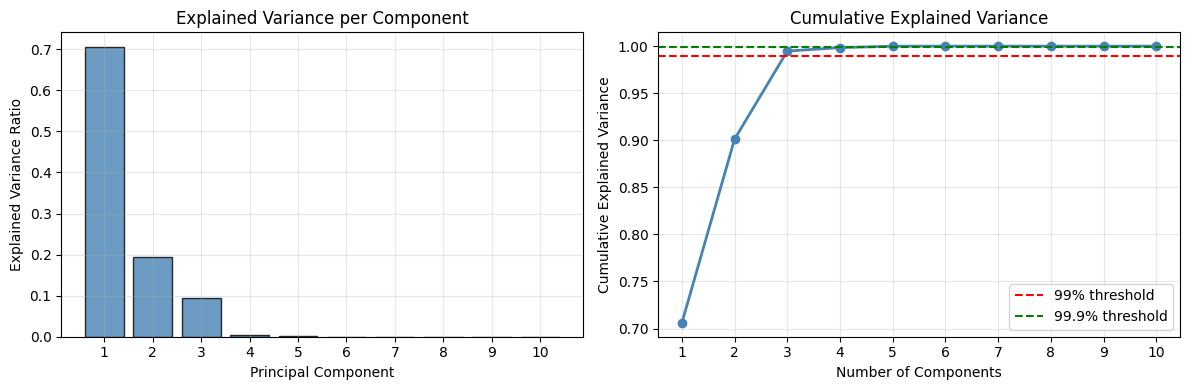


Selected r = 3 components (cumulative variance = 0.9948)
Reduced basis Vr shape: (10, 3)


In [41]:
# Stack all training snapshots: (60 * 1001, 10)
all_X_train = np.vstack([X for X, F in train_trajs])  # (60060, 10)

# Compute mean (already have X_mean from Part A, but recompute explicitly for PCA)
X_mean_pca = all_X_train.mean(axis=0)  # (10,)

# Center the data
all_X_centered = all_X_train - X_mean_pca  # (60060, 10)

# Fit PCA on all 10 components to see the full explained variance spectrum
pca_full = PCA(n_components=10)
pca_full.fit(all_X_centered)

explained_variance = pca_full.explained_variance_ratio_          # (10,)
cumulative_variance = np.cumsum(explained_variance)              # (10,)

print("Explained variance ratio per component:")
for i, (ev, cum) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"  PC{i+1}: {ev:.4f}  |  Cumulative: {cum:.4f}")

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, 11), explained_variance, color="steelblue", edgecolor="k", alpha=0.8)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Explained Variance per Component")
axes[0].set_xticks(range(1, 11))
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, 11), cumulative_variance, "o-", color="steelblue", lw=2)
axes[1].axhline(0.99, color="r", linestyle="--", label="99% threshold")
axes[1].axhline(0.999, color="g", linestyle="--", label="99.9% threshold")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xticks(range(1, 11))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("pca_explained_variance.png", dpi=600, bbox_inches="tight")
plt.show()

# Choose r based on cumulative variance >= 99%
r = int(np.argmax(cumulative_variance >= 0.99) + 1)
print(f"\nSelected r = {r} components (cumulative variance = {cumulative_variance[r-1]:.4f})")

# Fit final PCA with r components
pca = PCA(n_components=r)
pca.fit(all_X_centered)

# Vr: (10, r) — the reduced basis
Vr = pca.components_.T  # (10, r)
print(f"Reduced basis Vr shape: {Vr.shape}")

## Project data and train reduced LSTM

Reduced space shape: (60060, 3)
Z_mean: [0. 0. 0.]
Z_std:  [0.3443 0.181  0.1253]

Train samples: 58860
Test  samples: 14715
Input shape:  torch.Size([20, 4])  (window_p=20, features=4)
Target shape: torch.Size([3])  (next reduced state: 3 values)

Reduced LSTM:
LSTMModel(
  (lstm): LSTM(4, 64, batch_first=True)
  (linear): Linear(in_features=64, out_features=3, bias=True)
)
Total Parameters: 18,115
Epoch   1/150 | Train Loss: 1.914e-01 | Test Loss:  7.109e-04 | LR: 1.00e-03 | Best: 7.109e-04 @ epoch 1
Epoch   5/150 | Train Loss: 1.536e-04 | Test Loss:  1.078e-04 | LR: 1.00e-03 | Best: 8.386e-05 @ epoch 4
Epoch  10/150 | Train Loss: 5.218e-05 | Test Loss:  2.281e-05 | LR: 1.00e-03 | Best: 2.281e-05 @ epoch 10
Epoch  15/150 | Train Loss: 4.685e-05 | Test Loss:  2.206e-05 | LR: 1.00e-03 | Best: 1.920e-05 @ epoch 11
Epoch  20/150 | Train Loss: 8.978e-06 | Test Loss:  4.844e-06 | LR: 5.00e-04 | Best: 4.844e-06 @ epoch 20
Epoch  25/150 | Train Loss: 1.384e-05 | Test Loss:  8.482e-06 | LR: 5

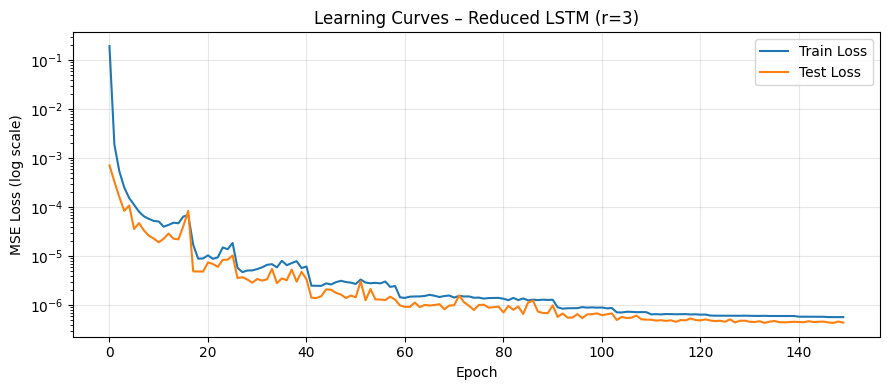

In [ ]:

# Project all training snapshots to reduced space
# z_n = Vr^T @ (x_n - x_mean)
def project_to_reduced(X, X_mean_pca, Vr):
    """X: (N, 10) → z: (N, r)"""
    return (X - X_mean_pca) @ Vr  # (N, r)

def lift_to_full(Z, X_mean_pca, Vr):
    """Z: (N, r) → x_hat: (N, 10)"""
    return Z @ Vr.T + X_mean_pca  # (N, 10)

# Normalization in reduced space 
all_Z_train = project_to_reduced(all_X_train, X_mean_pca, Vr)  # (60060, r)
Z_mean = all_Z_train.mean(axis=0).astype(np.float32)            # (r,)
Z_std  = all_Z_train.std(axis=0).astype(np.float32)             # (r,)
Z_std  = np.where(Z_std < 1e-8, 1.0, Z_std)

print(f"Reduced space shape: {all_Z_train.shape}")
print(f"Z_mean: {Z_mean.round(4)}")
print(f"Z_std:  {Z_std.round(4)}")

# Dataset for reduced LSTM 
class ReducedTrajectoryDataset(Dataset):
    def __init__(self, trajectories, window_p):
        self.samples = []

        for X, F in trajectories:
            # Project to reduced space
            Z = project_to_reduced(X, X_mean_pca, Vr).astype(np.float32)  # (1001, r)

            # Normalize reduced state
            Z_norm = (Z - Z_mean) / Z_std          # (1001, r)
            F_norm = ((F - F_mean) / F_std).astype(np.float32)  # (1001,)

            # Concatenate reduced state + force: (1001, r+1)
            ZF = np.column_stack([Z_norm, F_norm])

            # Sliding window
            for start in range(len(ZF) - window_p):
                end = start + window_p
                inp = ZF[start:end]       # (p, r+1)
                tgt = Z_norm[end]         # (r,)  — target: next reduced state

                self.samples.append((
                    torch.tensor(inp, dtype=torch.float32),
                    torch.tensor(tgt, dtype=torch.float32)
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


train_dataset_r = ReducedTrajectoryDataset(train_trajs, WINDOW_P)
test_dataset_r  = ReducedTrajectoryDataset(test_trajs,  WINDOW_P)

train_loader_r = DataLoader(train_dataset_r, batch_size=BATCH_SIZE, shuffle=True)
test_loader_r  = DataLoader(test_dataset_r,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nTrain samples: {len(train_dataset_r)}")
print(f"Test  samples: {len(test_dataset_r)}")

inp_r, tgt_r = train_dataset_r[0]
print(f"Input shape:  {inp_r.shape}  (window_p={WINDOW_P}, features={r+1})")
print(f"Target shape: {tgt_r.shape}  (next reduced state: {r} values)")

# Build reduced LSTM 
INPUT_SIZE_R  = r + 1   # r reduced state dims + 1 force
OUTPUT_SIZE_R = r       # predict next reduced state

model_r = LSTMModel(INPUT_SIZE_R, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE_R).to(device)
print(f"\nReduced LSTM:")
print(model_r)
print(f"Total Parameters: {sum(p.numel() for p in model_r.parameters()):,}")

# Training loop 
loss_fn_r   = nn.MSELoss()
optimizer_r = torch.optim.Adam(model_r.parameters(), lr=1e-3)
scheduler_r = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_r, mode='min', factor=0.5, patience=5
)

EPOCHS_R = 150

train_losses_r = []
test_losses_r  = []

best_test_loss_r  = float('inf')
best_epoch_r      = -1
epochs_no_improve_r = 0
best_model_state_r  = None

for epoch in range(EPOCHS_R):

    # Training
    model_r.train()
    epoch_train_loss = 0.0
    for Xb, yb in train_loader_r:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer_r.zero_grad()
        loss = loss_fn_r(model_r(Xb), yb)
        loss.backward()
        optimizer_r.step()
        epoch_train_loss += loss.item()
    avg_train_loss = epoch_train_loss / len(train_loader_r)

    # Evaluation
    model_r.eval()
    epoch_test_loss = 0.0
    with torch.no_grad():
        for Xb, yb in test_loader_r:
            Xb, yb = Xb.to(device), yb.to(device)
            epoch_test_loss += loss_fn_r(model_r(Xb), yb).item()
    avg_test_loss = epoch_test_loss / len(test_loader_r)

    train_losses_r.append(avg_train_loss)
    test_losses_r.append(avg_test_loss)

    scheduler_r.step(avg_test_loss)

    if avg_test_loss < best_test_loss_r:
        best_test_loss_r    = avg_test_loss
        best_epoch_r        = epoch + 1
        epochs_no_improve_r = 0
        best_model_state_r  = {k: v.cpu().clone() for k, v in model_r.state_dict().items()}
    else:
        epochs_no_improve_r += 1

    current_lr = optimizer_r.param_groups[0]['lr']

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS_R} | "
              f"Train Loss: {avg_train_loss:.3e} | "
              f"Test Loss:  {avg_test_loss:.3e} | "
              f"LR: {current_lr:.2e} | "
              f"Best: {best_test_loss_r:.3e} @ epoch {best_epoch_r}")

    if epochs_no_improve_r >= 15:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

model_r.load_state_dict(best_model_state_r)
print(f"\nLoaded best model from epoch {best_epoch_r} "
      f"(test loss = {best_test_loss_r:.3e})")

# Learning curves 
plt.figure(figsize=(9, 4))
plt.semilogy(train_losses_r, label="Train Loss")
plt.semilogy(test_losses_r,  label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log scale)")
plt.title("Learning Curves – Reduced LSTM (r=3)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("learning_curves_reduced.png", dpi=600, bbox_inches="tight")
plt.show()

## Lift back and comparison

RMSE comparison (test traj 8):
DOF    |  1-step Full |   1-step PCA |    Auto Full |     Auto PCA
--------------------------------------------------------------
u1     |    4.915e-06 |    2.538e-03 |    3.559e-04 |    2.535e-03
u2     |    8.239e-06 |    3.702e-03 |    6.791e-04 |    3.696e-03
u3     |    5.497e-06 |    2.711e-03 |    9.473e-04 |    2.706e-03
u4     |    1.297e-05 |    3.782e-04 |    1.139e-03 |    4.147e-04
u5     |    1.810e-05 |    4.431e-03 |    1.240e-03 |    4.439e-03
v1     |    6.106e-05 |    3.027e-03 |    1.103e-03 |    3.039e-03
v2     |    1.178e-04 |    1.874e-03 |    2.000e-03 |    1.902e-03
v3     |    8.143e-05 |    2.574e-03 |    2.752e-03 |    2.564e-03
v4     |    9.980e-05 |    4.122e-03 |    3.272e-03 |    4.110e-03
v5     |    9.938e-05 |    3.907e-03 |    3.607e-03 |    3.936e-03


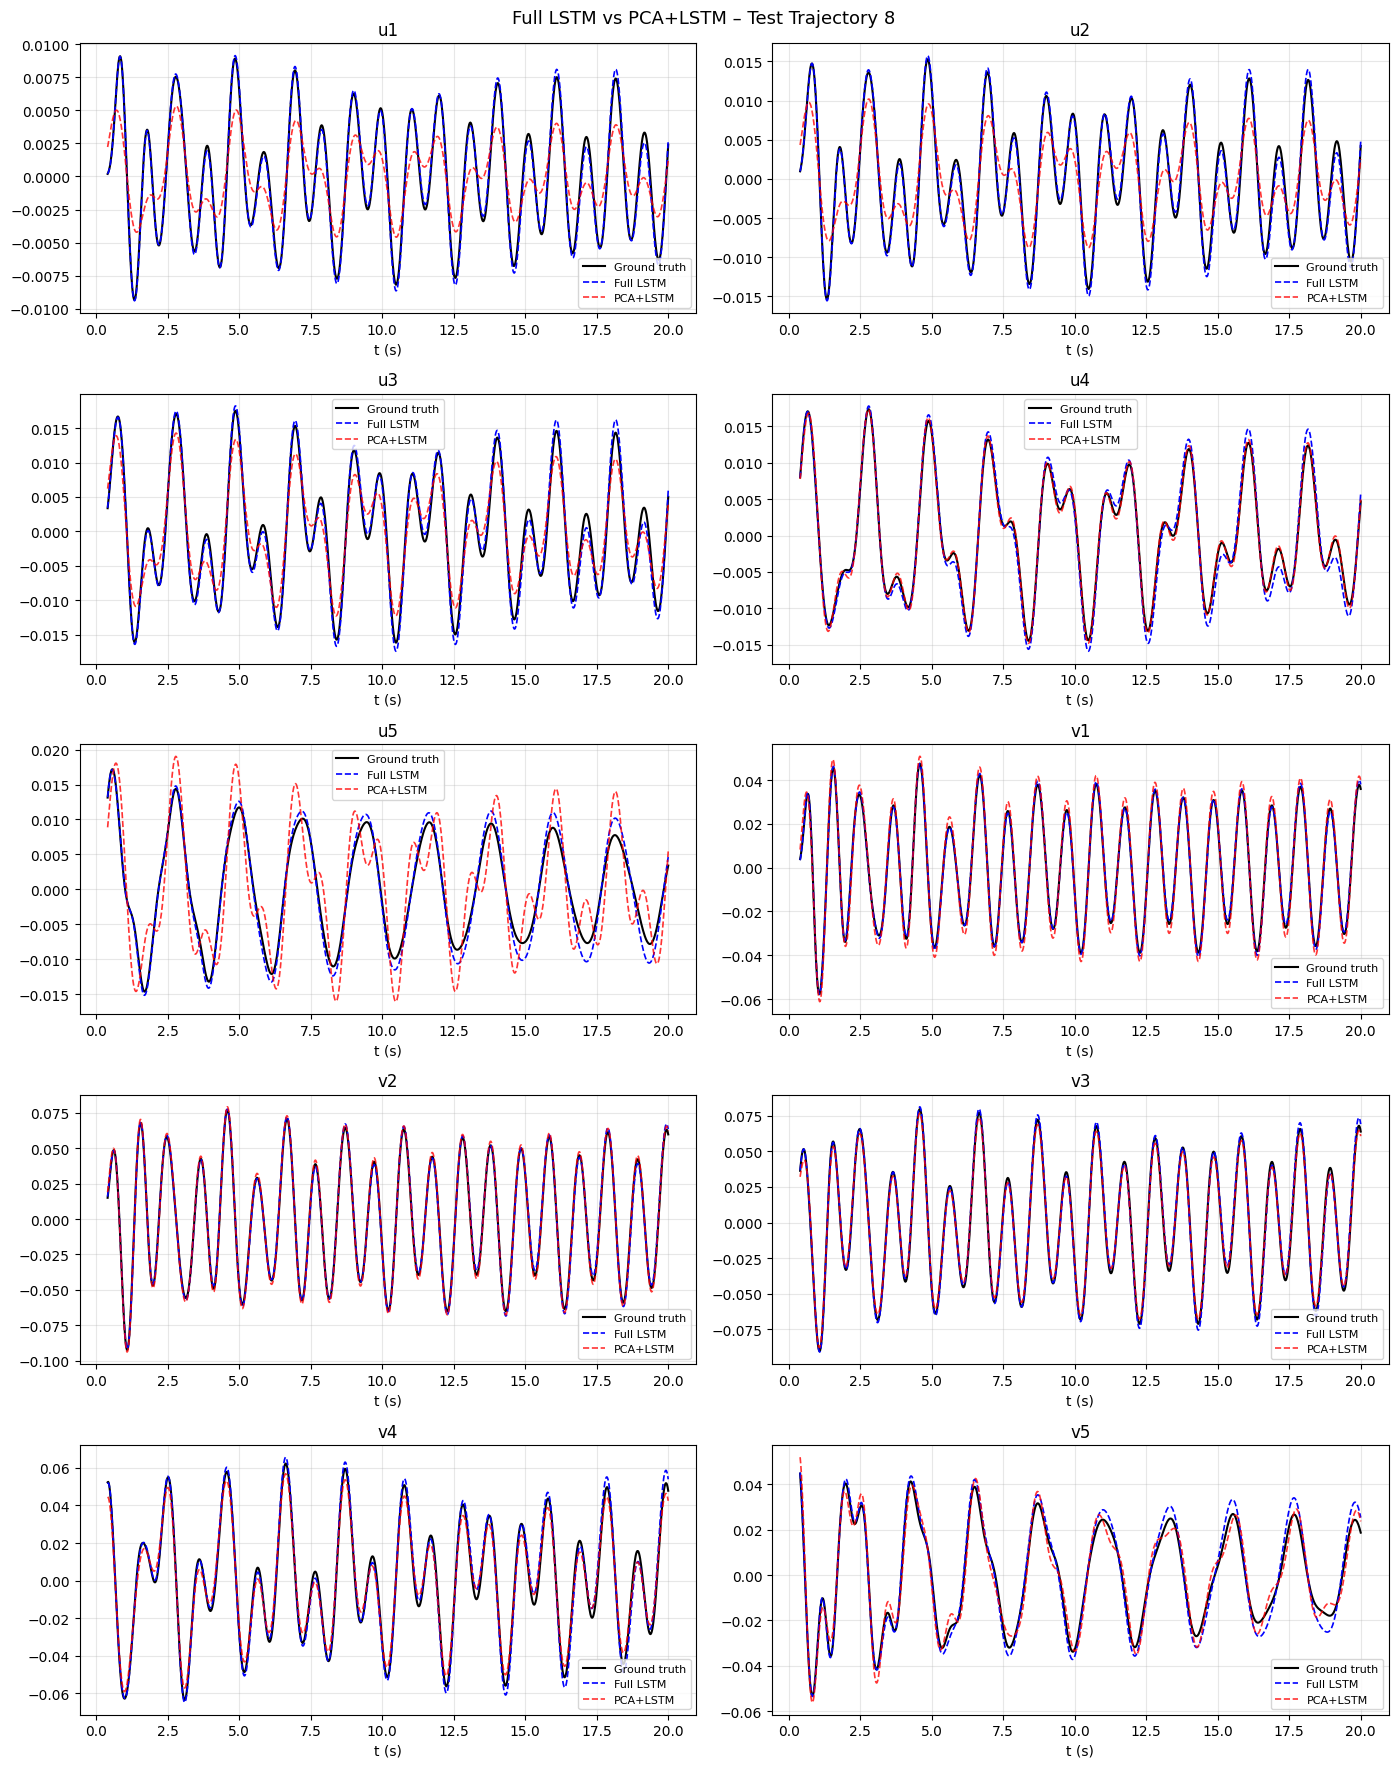

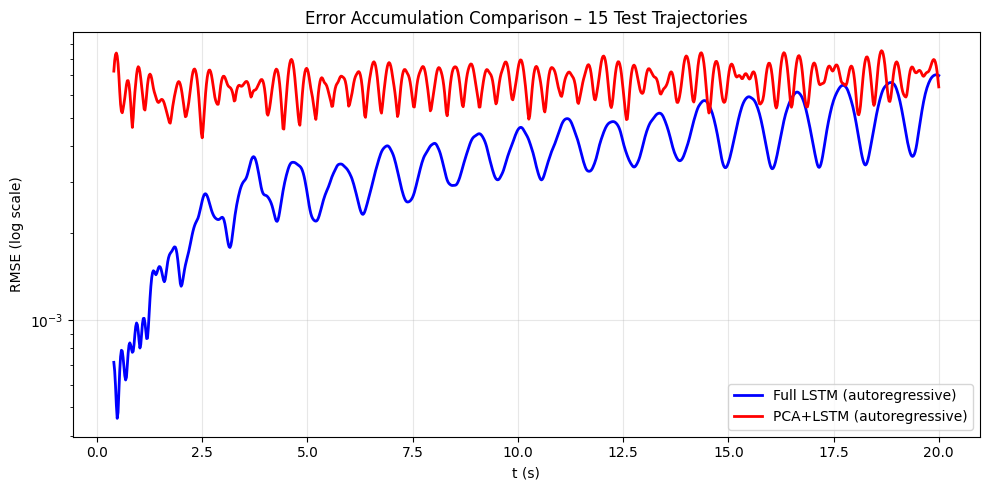

In [44]:
def one_step_ahead_reduced(model_r, X, F):
    """
    One-step ahead prediction in reduced space, lifted back to full space.
    X: (1001, 10) unnormalized
    F: (1001,)    unnormalized
    Returns: (1001 - WINDOW_P, 10) predictions in original scale
    """
    # Project to reduced space and normalize
    Z = project_to_reduced(X, X_mean_pca, Vr).astype(np.float32)  # (1001, r)
    Z_norm = (Z - Z_mean) / Z_std                                   # (1001, r)
    F_norm = ((F - F_mean) / F_std).astype(np.float32)             # (1001,)

    # Build input windows: (1001 - WINDOW_P, WINDOW_P, r+1)
    ZF = np.column_stack([Z_norm, F_norm])
    windows = np.stack([ZF[s:s+WINDOW_P] for s in range(len(ZF) - WINDOW_P)])

    model_r.eval()
    with torch.no_grad():
        inp  = torch.tensor(windows).to(device)
        pred = model_r(inp).cpu().numpy()   # (1001 - WINDOW_P, r) — normalized

    # Denormalize in reduced space
    Z_pred = pred * Z_std + Z_mean          # (1001 - WINDOW_P, r)

    # Lift back to full space
    return lift_to_full(Z_pred, X_mean_pca, Vr)  # (1001 - WINDOW_P, 10)


def autoregressive_rollout_reduced(model_r, X, F):
    """
    Autoregressive rollout in reduced space, lifted back to full space.
    X: (1001, 10) unnormalized
    F: (1001,)    unnormalized
    Returns: (1001 - WINDOW_P, 10) predictions in original scale
    """
    Z = project_to_reduced(X, X_mean_pca, Vr).astype(np.float32)  # (1001, r)
    Z_norm = (Z - Z_mean) / Z_std                                   # (1001, r)
    F_norm = ((F - F_mean) / F_std).astype(np.float32)             # (1001,)

    # Seed buffer with first p real reduced states
    buffer = Z_norm[:WINDOW_P].copy()  # (p, r)

    preds = []

    model_r.eval()
    with torch.no_grad():
        for step in range(len(Z_norm) - WINDOW_P):
            F_window = F_norm[step:step+WINDOW_P]              # (p,)
            inp = np.column_stack([buffer, F_window])          # (p, r+1)
            inp_tensor = torch.tensor(inp).unsqueeze(0).to(device)  # (1, p, r+1)

            pred = model_r(inp_tensor).cpu().numpy()[0]        # (r,)
            preds.append(pred)

            # Update buffer
            buffer[:-1] = buffer[1:]
            buffer[-1]  = pred

    preds = np.array(preds)             # (1001 - WINDOW_P, r) — normalized
    Z_pred = preds * Z_std + Z_mean     # denormalize in reduced space
    return lift_to_full(Z_pred, X_mean_pca, Vr)  # lift back to full space


# Evaluate on test trajectory 
X_test0, F_test0 = test_trajs[traj_num]
targets = X_test0[WINDOW_P:]  # ground truth

preds_1step_r = one_step_ahead_reduced(model_r, X_test0, F_test0)
preds_auto_r  = autoregressive_rollout_reduced(model_r, X_test0, F_test0)

# RMSE comparison
rmse_1step_full = np.sqrt(np.mean((preds_1step  - targets)**2, axis=0))
rmse_auto_full  = np.sqrt(np.mean((preds_auto   - targets)**2, axis=0))
rmse_1step_r    = np.sqrt(np.mean((preds_1step_r - targets)**2, axis=0))
rmse_auto_r     = np.sqrt(np.mean((preds_auto_r  - targets)**2, axis=0))

print(f"RMSE comparison (test traj {traj_num}):")
print(f"{'DOF':<6} | {'1-step Full':>12} | {'1-step PCA':>12} | {'Auto Full':>12} | {'Auto PCA':>12}")
print("-" * 62)
for col, r1f, r1r, raf, rar in zip(STATE_COLS, rmse_1step_full, rmse_1step_r, rmse_auto_full, rmse_auto_r):
    print(f"{col:<6} | {r1f:>12.3e} | {r1r:>12.3e} | {raf:>12.3e} | {rar:>12.3e}")

# Comparison plots: Full LSTM vs PCA+LSTM vs Ground truth 
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
fig.suptitle(f"Full LSTM vs PCA+LSTM – Test Trajectory {traj_num}", fontsize=13)

for ax, dof, label in zip(axes.flat, range(10), STATE_COLS):
    ax.plot(t_pred, targets[:,dof],        "k-",  lw=1.5, label="Ground truth")
    ax.plot(t_pred, preds_auto[:,dof],     "b--", lw=1.2, label="Full LSTM")
    ax.plot(t_pred, preds_auto_r[:,dof],   "r--", lw=1.2, label="PCA+LSTM", alpha=0.8)
    ax.set_xlabel("t (s)")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("full_vs_pca_lstm.png", dpi=600, bbox_inches="tight")
plt.show()

# Error accumulation comparison 
all_err_auto_r = []

for X, F in test_trajs:
    par = autoregressive_rollout_reduced(model_r, X, F)
    tgt = X[WINDOW_P:]
    all_err_auto_r.append(np.sqrt(np.mean((par - tgt)**2, axis=1)))

all_err_auto_r = np.array(all_err_auto_r)  # (15, 1001 - WINDOW_P)
ma_r = all_err_auto_r.mean(axis=0)

plt.figure(figsize=(10, 5))
plt.semilogy(t_pred, ma,   "b-", lw=2, label="Full LSTM (autoregressive)")
plt.semilogy(t_pred, ma_r, "r-", lw=2, label="PCA+LSTM (autoregressive)")
plt.xlabel("t (s)")
plt.ylabel("RMSE (log scale)")
plt.title("Error Accumulation Comparison – 15 Test Trajectories")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("error_accumulation_comparison.png", dpi=600, bbox_inches="tight")
plt.show()

## Full state LSTM vs PCA + LSTM +  lift

In [ ]:
# (α) Prediction accuracy — mean RMSE over all test trajectories
rmse_1step_full_all = []
rmse_1step_r_all    = []
rmse_auto_full_all  = []
rmse_auto_r_all     = []

for X, F in test_trajs:
    tgt = X[WINDOW_P:]

    p1f  = one_step_ahead(model, X, F)
    p1r  = one_step_ahead_reduced(model_r, X, F)
    paf  = autoregressive_rollout(model, X, F)
    par  = autoregressive_rollout_reduced(model_r, X, F)

    rmse_1step_full_all.append(np.sqrt(np.mean((p1f - tgt)**2)))
    rmse_1step_r_all.append(   np.sqrt(np.mean((p1r - tgt)**2)))
    rmse_auto_full_all.append( np.sqrt(np.mean((paf - tgt)**2)))
    rmse_auto_r_all.append(    np.sqrt(np.mean((par - tgt)**2)))

mean_rmse_1step_full = np.mean(rmse_1step_full_all)
mean_rmse_1step_r    = np.mean(rmse_1step_r_all)
mean_rmse_auto_full  = np.mean(rmse_auto_full_all)
mean_rmse_auto_r     = np.mean(rmse_auto_r_all)

# (δ) Training and inference time 
# Inference time: average over all test trajectories
t0 = time.time()
for X, F in test_trajs:
    autoregressive_rollout(model, X, F)
inference_time_full = (time.time() - t0) / len(test_trajs)

t0 = time.time()
for X, F in test_trajs:
    autoregressive_rollout_reduced(model_r, X, F)
inference_time_r = (time.time() - t0) / len(test_trajs)

# Summary table 
print("=" * 62)
print("FINAL COMPARISON: Full LSTM vs PCA+LSTM")
print("=" * 62)

print(f"\n{'Metric':<35} {'Full LSTM':>12} {'PCA+LSTM':>12}")
print("-" * 62)

# (α) Accuracy
print(f"{'(α) RMSE one-step (mean)':<35} {mean_rmse_1step_full:>12.3e} {mean_rmse_1step_r:>12.3e}")
print(f"{'(α) RMSE autoregressive (mean)':<35} {mean_rmse_auto_full:>12.3e} {mean_rmse_auto_r:>12.3e}")

# (β) Autoregressive behavior
print(f"{'(β) RMSE auto at t=20s':<35} {ma[-1]:>12.3e} {ma_r[-1]:>12.3e}")

# (γ) Reduced dimension
print(f"{'(γ) State space dimension':<35} {'10':>12} {str(r):>12}")
print(f"{'(γ) Explained variance':<35} {'100%':>12} {cumulative_variance[r-1]*100:>11.2f}%")

# (δ) Computational cost
print(f"{'(δ) Model parameters':<35} {sum(p.numel() for p in model.parameters()):>12,} {sum(p.numel() for p in model_r.parameters()):>12,}")
print(f"{'(δ) Training epochs':<35} {best_epoch:>12} {best_epoch_r:>12}")
print(f"{'(δ) Inference time per traj (s)':<35} {inference_time_full:>12.3f} {inference_time_r:>12.3f}")

print("=" * 62)

# Save to Excel 
rows = [
    {"Metric": "(α) RMSE one-step (mean)",        "Full LSTM": mean_rmse_1step_full, "PCA+LSTM": mean_rmse_1step_r},
    {"Metric": "(α) RMSE autoregressive (mean)",  "Full LSTM": mean_rmse_auto_full,  "PCA+LSTM": mean_rmse_auto_r},
    {"Metric": "(β) RMSE auto at t=20s",          "Full LSTM": ma[-1],               "PCA+LSTM": ma_r[-1]},
    {"Metric": "(γ) State space dimension",        "Full LSTM": 10,                   "PCA+LSTM": r},
    {"Metric": "(γ) Explained variance (%)",       "Full LSTM": 100.0,                "PCA+LSTM": round(cumulative_variance[r-1]*100, 2)},
    {"Metric": "(δ) Model parameters",             "Full LSTM": sum(p.numel() for p in model.parameters()),   "PCA+LSTM": sum(p.numel() for p in model_r.parameters())},
    {"Metric": "(δ) Training epochs",              "Full LSTM": best_epoch,           "PCA+LSTM": best_epoch_r},
    {"Metric": "(δ) Inference time per traj (s)",  "Full LSTM": inference_time_full,  "PCA+LSTM": inference_time_r},
]

df_comparison = pd.DataFrame(rows)
df_comparison.to_excel("final_comparison.xlsx", index=False)
print("\nSaved: final_comparison.xlsx")

FINAL COMPARISON: Full LSTM vs PCA+LSTM

Metric                                 Full LSTM     PCA+LSTM
--------------------------------------------------------------
(α) RMSE one-step (mean)               1.271e-04    6.429e-03
(α) RMSE autoregressive (mean)         4.175e-03    6.877e-03
(β) RMSE auto at t=20s                 6.997e-03    6.393e-03
(γ) State space dimension                     10            3
(γ) Explained variance                      100%       99.48%
(δ) Model parameters                      20,362       18,115
(δ) Training epochs                          149          148
(δ) Inference time per traj (s)            0.600        0.593

Saved: final_comparison.xlsx
